# E0_quantum_advantage -- ¿El ganador de E0A supera a su CNN análoga?

**Objetivo**: comparar `WINNER_MODEL` (el candidato QCNN que ganó E0A -- Hur,
Wei o Gong) contra su CNN clásica análoga (`cnn_<WINNER_MODEL>_analoga`, con
conteo de parámetros comparable), mismo protocolo de entrenamiento y mismo
criterio estadístico que `E0A_seleccion_candidato.ipynb`.

**Resultado informativo para la narrativa de Quantum Advantage del paper --
no alimenta ninguna decisión de E0B/E1/E2** (esas fases usan `WINNER_MODEL`
directamente, no el resultado de esta comparación). Ver la celda de handoff
al final.

**Nota sobre significancia estadística**: con solo 5 semillas por
configuración, un test de permutación de signo pareado tiene poca potencia
para detectar diferencias moderadas -- en E0A, con diferencias de media
bastante más grandes entre Hur/Wei/Gong, el patrón ya era ajustado. Por eso
este notebook reporta **desde el inicio** el solape de los IC bootstrap BCa
como evidencia complementaria a la significancia formal, no como un parche
posterior si el test de permutación no alcanza a rechazar.


In [3]:
import json
import pathlib
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qcnn_benchmark.config import load_config
from qcnn_benchmark.data import load_mnist_pool, load_fashion_mnist_pool
from qcnn_benchmark.representations import build_pca_dataset, build_amplitude_dataset
from qcnn_benchmark.models import (
    qcnn_hur, qcnn_wei, qcnn_gong,
    cnn_hur_analoga, cnn_wei_analoga, cnn_gong_analoga,
)
from qcnn_benchmark.training import train_binary_classifier, uniform_pi_init, normal_init
from qcnn_benchmark.metrics import batch_accuracy
from qcnn_benchmark.stats import (
    bootstrap_bca_ci,
    paired_sign_permutation_test,
    holm_correction,
    cohens_dz,
    probability_of_superiority,
)


## 0. INPUTS MANUALES -- completar antes de correr

`WINNER_MODEL` es el valor que imprimió la Sec. 10 de
`E0A_seleccion_candidato.ipynb` ("Selecciona WINNER_MODEL = '...'"). Este
notebook **no** lo calcula ni lo asume -- si no lo completas correctamente
abajo, el assert siguiente lo impide.


In [4]:
WINNER_MODEL = 'wei'  # <-- completar con el valor impreso al final de E0A_seleccion_candidato.ipynb
assert WINNER_MODEL in ("hur", "wei", "gong"), "Completa WINNER_MODEL arriba"
CNN_ANALOGA_MODEL = f"cnn_{WINNER_MODEL}_analoga"
print("WINNER_MODEL:", WINNER_MODEL)
print("CNN análoga a comparar:", CNN_ANALOGA_MODEL)


WINNER_MODEL: wei
CNN análoga a comparar: cnn_wei_analoga


## 1. Configuración declarativa

In [5]:
FAST_SMOKE_TEST = False  # True = 2 semillas, pocas actualizaciones, solo para validar el pipeline

_CONFIG_CANDIDATES = [pathlib.Path("configs/e0_quantum_advantage.yaml"), pathlib.Path("../configs/e0_quantum_advantage.yaml")]
CONFIG_PATH = next(p for p in _CONFIG_CANDIDATES if p.exists())
config = load_config(CONFIG_PATH)

# WINNER_MODEL se decide en tiempo de ejecucion (Sec. 0), no puede quedar
# fijo en el YAML -- ver el comentario en configs/e0_quantum_advantage.yaml.
config = config.model_copy(update={"models": [WINNER_MODEL, CNN_ANALOGA_MODEL]})

if FAST_SMOKE_TEST:
    config = config.model_copy(update={
        "n_seeds": 2,  # 2 es el minimo que scipy.stats.bootstrap acepta por muestra
        "protocol": config.protocol.model_copy(update={"n_updates": 10, "val_check_every": 5, "patience_checks": 2}),
    })

print("experiment_id:", config.experiment_id)
print("canonical_hash:", config.canonical_hash(), "(FAST_SMOKE_TEST)" if FAST_SMOKE_TEST else "")
print("datasets:", [d.name for d in config.datasets])
print("models:", config.models)
print("run_seeds:", config.run_seeds())
print("protocol:", config.protocol)
print("statistical_criterion:", config.statistical_criterion)


experiment_id: E0_QUANTUM_ADVANTAGE
canonical_hash: 12aaded3bf0b 
datasets: ['coat_vs_shirt', '4_vs_9', '1_vs_0']
models: ['wei', 'cnn_wei_analoga']
run_seeds: [0, 1, 2, 3, 4]
protocol: batch_size=25 n_updates=500 learning_rate=0.01 beta1=0.9 beta2=0.999 clip_norm=5.0 val_check_every=10 patience_checks=5 min_delta=0.0001
statistical_criterion: aggregation='mean_per_dataset' ci_method='bootstrap_bca' n_bootstrap=10000 confidence_level=0.95 comparison_test='paired_sign_permutation' multiple_comparison_correction='holm' alpha=0.05


## 2. Registro de modelos y representaciones

In [6]:
QCNN_REGISTRY = {
    "hur": {"module": qcnn_hur, "init": uniform_pi_init, "normalize": True,
            "build_rep": lambda x, y, pos, neg: build_pca_dataset(x, y, pos, neg, n_components=16, verbose=False)},
    "wei": {"module": qcnn_wei, "init": normal_init, "normalize": False,
            "build_rep": lambda x, y, pos, neg: build_amplitude_dataset(x, y, pos, neg, verbose=False)},
    "gong": {"module": qcnn_gong, "init": uniform_pi_init, "normalize": True,
             "build_rep": lambda x, y, pos, neg: build_pca_dataset(x, y, pos, neg, n_components=8, verbose=False)},
}

CNN_ANALOGA_REGISTRY = {
    "cnn_hur_analoga": {"module": cnn_hur_analoga, "init": cnn_hur_analoga.init, "normalize": True,
                         "build_rep": lambda x, y, pos, neg: build_pca_dataset(x, y, pos, neg, n_components=cnn_hur_analoga.INPUT_SIZE, verbose=False)},
    "cnn_wei_analoga": {"module": cnn_wei_analoga, "init": cnn_wei_analoga.init, "normalize": True,
                         "build_rep": lambda x, y, pos, neg: build_pca_dataset(x, y, pos, neg, n_components=cnn_wei_analoga.INPUT_SIZE, verbose=False)},
    "cnn_gong_analoga": {"module": cnn_gong_analoga, "init": cnn_gong_analoga.init, "normalize": True,
                          "build_rep": lambda x, y, pos, neg: build_pca_dataset(x, y, pos, neg, n_components=cnn_gong_analoga.INPUT_SIZE, verbose=False)},
}

MODEL_REGISTRY = {**QCNN_REGISTRY, **CNN_ANALOGA_REGISTRY}

_POOL_CACHE = {}


def get_pool(source, normalize):
    key = (source, normalize)
    if key not in _POOL_CACHE:
        loader = load_mnist_pool if source == "mnist" else load_fashion_mnist_pool
        _POOL_CACHE[key] = loader(normalize=normalize)
    return _POOL_CACHE[key]


## 3. Ejecución (matriz: datasets × {WINNER_MODEL, CNN análoga} × semillas)

In [7]:
RESULTS_DIR = pathlib.Path("results") if pathlib.Path("results").exists() else pathlib.Path("../results")
raw_path = RESULTS_DIR / f"e0_quantum_advantage_raw_{config.canonical_hash()}.csv"

rows = []
t_start = time.time()
for dataset in config.datasets:
    for model_name in config.models:
        entry = MODEL_REGISTRY[model_name]
        x_all, y_all = get_pool(dataset.source, entry["normalize"])
        rep = entry["build_rep"](x_all, y_all, dataset.class_pos, dataset.class_neg)

        for seed in config.run_seeds():
            tag = f"{dataset.name}-{model_name}-seed{seed}"
            result = train_binary_classifier(
                entry["module"].predict_proba, entry["module"].TOTAL_PARAMS, rep, entry["init"],
                run_seed=seed,
                batch_size=config.protocol.batch_size,
                n_updates=config.protocol.n_updates,
                learning_rate=config.protocol.learning_rate,
                beta1=config.protocol.beta1,
                beta2=config.protocol.beta2,
                clip_norm=config.protocol.clip_norm,
                val_check_every=config.protocol.val_check_every,
                patience_checks=config.protocol.patience_checks,
                min_delta=config.protocol.min_delta,
                verbose=False,
                tag=tag,
            )
            train_acc = batch_accuracy(entry["module"].predict_proba, result["params"], rep["X_train"], rep["y_train"])
            test_acc = batch_accuracy(entry["module"].predict_proba, result["params"], rep["X_test"], rep["y_test"])
            rows.append({
                "dataset": dataset.name, "model": model_name, "seed": seed,
                "train_acc": train_acc, "test_acc": test_acc,
                "n_updates_run": result["n_updates_run"], "stopped_early_at": result["stopped_early_at"],
                "best_val_loss": result["best_val_loss"],
            })
            print(f"[{tag}] test_acc={test_acc:.4f}  (t={time.time()-t_start:.0f}s acumulado)")

            raw_df = pd.DataFrame(rows)
            raw_df.to_csv(raw_path, index=False)  # checkpoint incremental

print("Total:", time.time() - t_start, "s")
raw_df = pd.DataFrame(rows)
raw_df


[coat_vs_shirt-wei-seed0] test_acc=0.7720  (t=408s acumulado)
[coat_vs_shirt-wei-seed1] test_acc=0.7750  (t=814s acumulado)
[coat_vs_shirt-wei-seed2] test_acc=0.7700  (t=1178s acumulado)
[coat_vs_shirt-wei-seed3] test_acc=0.7740  (t=1582s acumulado)
[coat_vs_shirt-wei-seed4] test_acc=0.7640  (t=1988s acumulado)
[coat_vs_shirt-cnn_wei_analoga-seed0] test_acc=0.6470  (t=2013s acumulado)
[coat_vs_shirt-cnn_wei_analoga-seed1] test_acc=0.7460  (t=2058s acumulado)
[coat_vs_shirt-cnn_wei_analoga-seed2] test_acc=0.7170  (t=2099s acumulado)
[coat_vs_shirt-cnn_wei_analoga-seed3] test_acc=0.7220  (t=2129s acumulado)
[coat_vs_shirt-cnn_wei_analoga-seed4] test_acc=0.6380  (t=2167s acumulado)
[4_vs_9-wei-seed0] test_acc=0.9580  (t=2574s acumulado)
[4_vs_9-wei-seed1] test_acc=0.9590  (t=2978s acumulado)
[4_vs_9-wei-seed2] test_acc=0.9440  (t=3249s acumulado)
[4_vs_9-wei-seed3] test_acc=0.9550  (t=3653s acumulado)
[4_vs_9-wei-seed4] test_acc=0.9530  (t=4057s acumulado)
[4_vs_9-cnn_wei_analoga-seed0] t

,dataset,model,seed,train_acc,test_acc,n_updates_run,stopped_early_at,best_val_loss
0,coat_vs_shirt,wei,0,0.747,0.772,500,NaN,0.526474
1,coat_vs_shirt,wei,1,0.782,0.775,500,NaN,0.516676
2,coat_vs_shirt,wei,2,0.744,0.770,450,450.0,0.533624
3,coat_vs_shirt,wei,3,0.774,0.774,500,NaN,0.514200
4,coat_vs_shirt,wei,4,0.771,0.764,500,NaN,0.482949
5,coat_vs_shirt,cnn_wei_analoga,0,0.647,0.647,250,250.0,0.631885
6,coat_vs_shirt,cnn_wei_analoga,1,0.731,0.746,500,NaN,0.530220
7,coat_vs_shirt,cnn_wei_analoga,2,0.702,0.717,450,450.0,0.589900
8,coat_vs_shirt,cnn_wei_analoga,3,0.701,0.722,340,340.0,0.561865
9,coat_vs_shirt,cnn_wei_analoga,4,0.636,0.638,420,420.0,0.628967


## 4. Resultados crudos

In [8]:
raw_df = pd.read_csv(raw_path)
display(raw_df)
raw_df.pivot_table(index="dataset", columns="model", values="test_acc", aggfunc=list)


,dataset,model,seed,train_acc,test_acc,n_updates_run,stopped_early_at,best_val_loss
0,coat_vs_shirt,wei,0,0.747,0.772,500,NaN,0.526474
1,coat_vs_shirt,wei,1,0.782,0.775,500,NaN,0.516676
2,coat_vs_shirt,wei,2,0.744,0.770,450,450.0,0.533624
3,coat_vs_shirt,wei,3,0.774,0.774,500,NaN,0.514200
4,coat_vs_shirt,wei,4,0.771,0.764,500,NaN,0.482949
5,coat_vs_shirt,cnn_wei_analoga,0,0.647,0.647,250,250.0,0.631885
6,coat_vs_shirt,cnn_wei_analoga,1,0.731,0.746,500,NaN,0.530220
7,coat_vs_shirt,cnn_wei_analoga,2,0.702,0.717,450,450.0,0.589900
8,coat_vs_shirt,cnn_wei_analoga,3,0.701,0.722,340,340.0,0.561865
9,coat_vs_shirt,cnn_wei_analoga,4,0.636,0.638,420,420.0,0.628967


model,cnn_wei_analoga,wei
dataset,,
1_vs_0,"[0.993, 0.994, 0.997, 0.966, 0.998]","[0.995, 0.993, 0.988, 0.994, 0.992]"
4_vs_9,"[0.793, 0.878, 0.853, 0.816, 0.631]","[0.958, 0.959, 0.944, 0.955, 0.953]"
coat_vs_shirt,"[0.647, 0.746, 0.717, 0.722, 0.638]","[0.772, 0.775, 0.77, 0.774, 0.764]"


## 5. Métricas agregadas (media ± IC bootstrap BCa por dataset)

In [9]:
agg_rows = []
for (dataset_name, model_name), group in raw_df.groupby(["dataset", "model"]):
    accs = group["test_acc"].to_numpy()
    lo, hi = bootstrap_bca_ci(
        accs, n_bootstrap=config.statistical_criterion.n_bootstrap,
        confidence_level=config.statistical_criterion.confidence_level,
        rng=np.random.default_rng(0),
    )
    agg_rows.append({
        "dataset": dataset_name, "model": model_name,
        "mean_test_acc": float(np.mean(accs)), "ci_lo": lo, "ci_hi": hi, "n_seeds": len(accs),
    })

agg_df = pd.DataFrame(agg_rows)
agg_df


,dataset,model,mean_test_acc,ci_lo,ci_hi,n_seeds
0,1_vs_0,cnn_wei_analoga,0.9896,0.9724,0.9962,5
1,1_vs_0,wei,0.9924,0.9896,0.9940,5
2,4_vs_9,cnn_wei_analoga,0.7942,0.6958,0.8486,5
3,4_vs_9,wei,0.9538,0.9476,0.9574,5
4,coat_vs_shirt,cnn_wei_analoga,0.6940,0.6556,0.7296,5
5,coat_vs_shirt,wei,0.7710,0.7668,0.7736,5


## 6. Análisis estadístico (permutación pareada + Holm, tamaños de efecto, solape de IC)

Además de la permutación pareada + Holm (igual que E0A), se agrega
`ci_overlap`: si el IC de `model_a` y el de `model_b` se solapan. Con n=5
semillas, un IC que no se solapa es evidencia complementaria razonable de
que la diferencia es real, incluso si el test de permutación de signo (más
conservador con este tamaño de muestra) no alcanza `p_holm < alpha`.


In [10]:
from itertools import combinations

comparison_rows = []
for dataset_name, group in raw_df.groupby("dataset"):
    pivot = group.pivot(index="seed", columns="model", values="test_acc")
    agg_lookup = agg_df[agg_df["dataset"] == dataset_name].set_index("model")
    for model_a, model_b in combinations(config.models, 2):
        x, y = pivot[model_a].to_numpy(), pivot[model_b].to_numpy()
        p_value, mean_diff = paired_sign_permutation_test(
            x, y, n_permutations=config.statistical_criterion.n_bootstrap,
            rng=np.random.default_rng(0),
        )
        lo_a, hi_a = agg_lookup.loc[model_a, ["ci_lo", "ci_hi"]]
        lo_b, hi_b = agg_lookup.loc[model_b, ["ci_lo", "ci_hi"]]
        ci_overlap = (lo_a <= hi_b) and (lo_b <= hi_a)
        comparison_rows.append({
            "dataset": dataset_name, "model_a": model_a, "model_b": model_b,
            "mean_diff_a_minus_b": mean_diff, "p_value": p_value,
            "cohens_dz": cohens_dz(x, y), "prob_superiority_a_over_b": probability_of_superiority(x, y),
            "ci_overlap": bool(ci_overlap),
        })

comparisons_df = pd.DataFrame(comparison_rows)
adjusted, rejected = holm_correction(comparisons_df["p_value"], alpha=config.statistical_criterion.alpha)
comparisons_df["p_value_holm"] = adjusted
comparisons_df["significant"] = rejected
comparisons_df


,dataset,model_a,model_b,mean_diff_a_minus_b,p_value,cohens_dz,prob_superiority_a_over_b,ci_overlap,p_value_holm,significant
0,1_vs_0,wei,cnn_wei_analoga,0.0028,0.8750,0.190208,0.4,True,0.8750,False
1,4_vs_9,wei,cnn_wei_analoga,0.1596,0.0625,1.643719,1.0,False,0.1875,False
2,coat_vs_shirt,wei,cnn_wei_analoga,0.0770,0.0625,1.699609,1.0,False,0.1875,False


## 7. Figuras y tablas

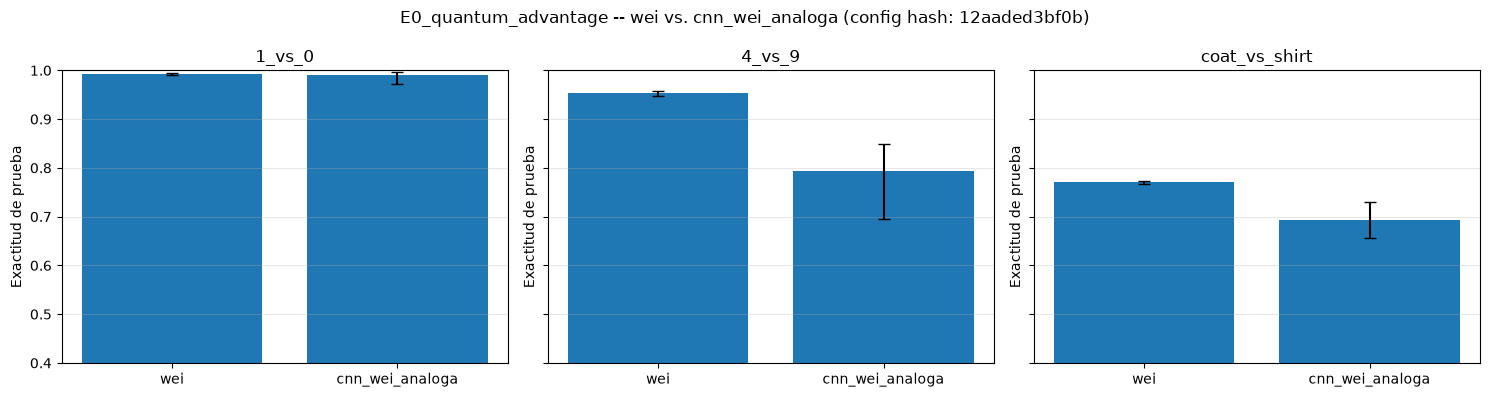

In [11]:
fig, axes = plt.subplots(1, len(config.datasets), figsize=(5 * len(config.datasets), 4), sharey=True)
if len(config.datasets) == 1:
    axes = [axes]
for ax, (dataset_name, group) in zip(axes, agg_df.groupby("dataset")):
    group = group.set_index("model").loc[config.models]
    yerr = [group["mean_test_acc"] - group["ci_lo"], group["ci_hi"] - group["mean_test_acc"]]
    ax.bar(group.index, group["mean_test_acc"], yerr=yerr, capsize=4)
    ax.set_title(dataset_name)
    ax.set_ylabel("Exactitud de prueba")
    ax.set_ylim(0.4, 1.0)
    ax.grid(alpha=0.3, axis="y")
plt.suptitle(f"E0_quantum_advantage -- {WINNER_MODEL} vs. {CNN_ANALOGA_MODEL} (config hash: " + config.canonical_hash() + ")")
plt.tight_layout()
plt.show()


In [12]:
display(comparisons_df.style.format({
    "mean_diff_a_minus_b": "{:+.4f}", "p_value": "{:.4f}", "p_value_holm": "{:.4f}",
    "cohens_dz": "{:.2f}", "prob_superiority_a_over_b": "{:.2f}",
}))


,dataset,model_a,model_b,mean_diff_a_minus_b,p_value,cohens_dz,prob_superiority_a_over_b,ci_overlap,p_value_holm,significant
0,1_vs_0,wei,cnn_wei_analoga,+0.0028,0.8750,0.19,0.40,True,0.8750,False
1,4_vs_9,wei,cnn_wei_analoga,+0.1596,0.0625,1.64,1.00,False,0.1875,False
2,coat_vs_shirt,wei,cnn_wei_analoga,+0.0770,0.0625,1.70,1.00,False,0.1875,False


## 8. Conclusión -- ¿gana la QCNN o la CNN análoga?

In [13]:
alpha = config.statistical_criterion.alpha
print(f"WINNER_MODEL={WINNER_MODEL} vs. {CNN_ANALOGA_MODEL} -- alpha={alpha}\n")

for dataset_name, group in agg_df.groupby("dataset"):
    ranked = group.sort_values("mean_test_acc", ascending=False).reset_index(drop=True)
    winner, runner_up = ranked.loc[0, "model"], ranked.loc[1, "model"]
    row = comparisons_df[
        (comparisons_df["dataset"] == dataset_name)
        & (comparisons_df[["model_a", "model_b"]].isin([winner, runner_up]).all(axis=1))
    ]
    is_significant = bool(row["significant"].iloc[0]) if len(row) else None
    ci_overlap = bool(row["ci_overlap"].iloc[0]) if len(row) else None
    print(f"{dataset_name}: gana {winner} ({ranked.loc[0, 'mean_test_acc']:.4f}) "
          f"sobre {runner_up} ({ranked.loc[1, 'mean_test_acc']:.4f}) -- "
          f"{'significativo' if is_significant else 'NO significativo'} tras Holm, "
          f"IC {'se solapan' if ci_overlap else 'NO se solapan'}")


WINNER_MODEL=wei vs. cnn_wei_analoga -- alpha=0.05

1_vs_0: gana wei (0.9924) sobre cnn_wei_analoga (0.9896) -- NO significativo tras Holm, IC se solapan
4_vs_9: gana wei (0.9538) sobre cnn_wei_analoga (0.7942) -- NO significativo tras Holm, IC NO se solapan
coat_vs_shirt: gana wei (0.7710) sobre cnn_wei_analoga (0.6940) -- NO significativo tras Holm, IC NO se solapan


## 9. Registro de reproducibilidad

In [14]:
import pennylane, sklearn, scipy

provenance = {
    "experiment_id": config.experiment_id,
    "winner_model": WINNER_MODEL,
    "cnn_analoga_model": CNN_ANALOGA_MODEL,
    "canonical_hash": config.canonical_hash(),
    "config": json.loads(config.canonical_json()),
    "fast_smoke_test": FAST_SMOKE_TEST,
    "timestamp_utc": pd.Timestamp.utcnow().isoformat(),
    "raw_results_path": str(raw_path),
    "package_versions": {
        "pennylane": pennylane.__version__,
        "numpy": np.__version__,
        "scipy": scipy.__version__,
        "scikit_learn": sklearn.__version__,
        "pandas": pd.__version__,
    },
}

provenance_path = RESULTS_DIR / f"e0_quantum_advantage_provenance_{config.canonical_hash()}.json"
provenance_path.write_text(json.dumps(provenance, indent=2, ensure_ascii=False))
print("Provenance guardado en:", provenance_path)
print(json.dumps(provenance, indent=2, ensure_ascii=False))


Provenance guardado en: ../results/e0_quantum_advantage_provenance_12aaded3bf0b.json
{
  "experiment_id": "E0_QUANTUM_ADVANTAGE",
  "winner_model": "wei",
  "cnn_analoga_model": "cnn_wei_analoga",
  "canonical_hash": "12aaded3bf0b",
  "config": {
    "datasets": [
      {
        "class_neg": 6,
        "class_pos": 4,
        "name": "coat_vs_shirt",
        "source": "fashion_mnist"
      },
      {
        "class_neg": 9,
        "class_pos": 4,
        "name": "4_vs_9",
        "source": "mnist"
      },
      {
        "class_neg": 0,
        "class_pos": 1,
        "name": "1_vs_0",
        "source": "mnist"
      }
    ],
    "description": "¿El QCNN ganador de E0A supera a una CNN clásica con conteo de parámetros comparable? Resultado informativo para la narrativa de Quantum Advantage del paper -- no alimenta ninguna decisión de E0B/E1/E2 (esas fases usan WINNER_MODEL directamente, no el resultado de esta comparación). Dado lo observado en E0A (n=5 semillas), es esperable que e

/var/folders/l9/hx3k3fcs03d6gz71m2n3t1c80000gn/T/ipykernel_36912/6064357.py:10: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  "timestamp_utc": pd.Timestamp.utcnow().isoformat(),


## 10. Handoff

In [15]:
print("=" * 78)
print("Este resultado es informativo para la narrativa de Quantum Advantage del paper.")
print("No se requiere ningun valor de aqui para E0B/E1/E2 (usan WINNER_MODEL")
print("directamente, no el resultado de esta comparacion).")
print("=" * 78)


Este resultado es informativo para la narrativa de Quantum Advantage del paper.
No se requiere ningun valor de aqui para E0B/E1/E2 (usan WINNER_MODEL
directamente, no el resultado de esta comparacion).
